# shades2shapes — worked example

This notebook reproduces the example of the README with the Python API:

1. diagnose each of the three bloom images (`N_scintillans.png`, `Aphanizomenon_sp.png`,
   `M_rubrum.png`);
2. discriminate the three species and look at which features separate them;
3. check how well a compact feature set generalises when whole images are held out;
4. classify new tiles with the fitted model.

Run it from the `examples/` folder. If `shades2shapes` is not installed (`pip install -e .`
from the repository root), the cell below falls back to the repository's `src/` folder.

In [1]:
import sys
from pathlib import Path

try:
    import shades2shapes as s2s
except ImportError:  # not installed: use the source tree of the repository
    src = next(p / "src" for p in [Path.cwd(), *Path.cwd().parents]
               if (p / "src" / "shades2shapes").is_dir())
    sys.path.insert(0, str(src))
    import shades2shapes as s2s

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage import io

%matplotlib inline
pd.set_option("display.precision", 3)
print("shades2shapes", s2s.__version__)

HERE = Path.cwd()
IMAGES = {name: HERE / f"{name}.png" for name in ("N_scintillans", "Aphanizomenon_sp", "M_rubrum")}
OUT = HERE / "out_notebook"   # the shipped reference outputs are in out_discrimination/
OUT.mkdir(exist_ok=True)

shades2shapes 0.1.0


## 1. The input images

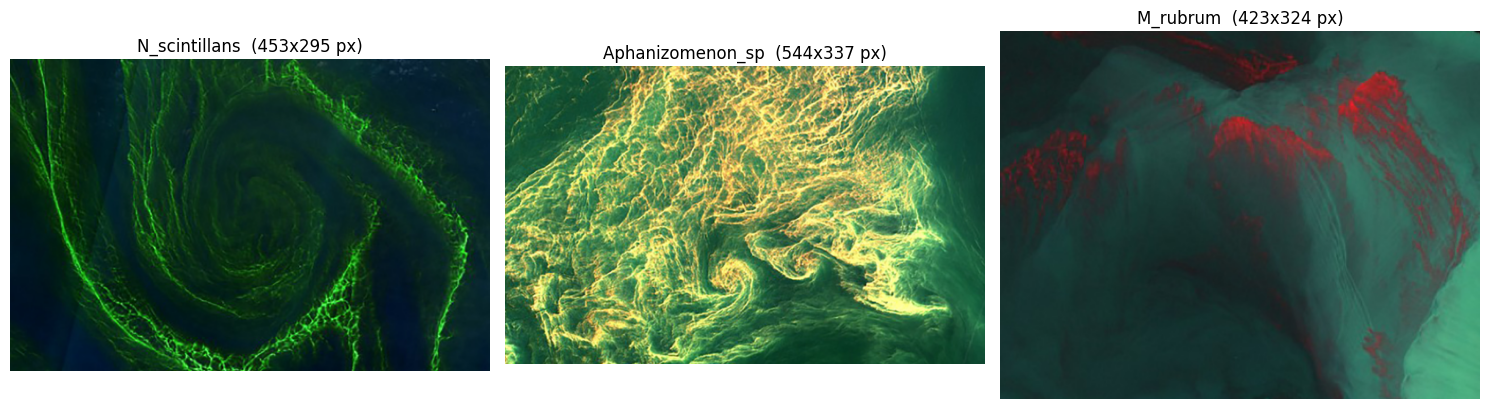

In [2]:
fig, axes = plt.subplots(1, len(IMAGES), figsize=(5 * len(IMAGES), 4.5))
for ax, (name, path) in zip(axes, IMAGES.items()):
    img = io.imread(path)
    ax.imshow(img)
    ax.set_title(f"{name}  ({img.shape[1]}x{img.shape[0]} px)")
    ax.axis("off")
fig.tight_layout()

## 2. Diagnose each image

`diagnose` computes filaments, network topology, orientation, eddies, texture and complexity.
`channel="auto"` picks the band with the highest contrast. Every option of `DiagnosisConfig`
can be passed as a keyword (e.g. `mask_method="local"`, `pixel_size=0.03, unit="km"`).

In [3]:
diags = {name: s2s.diagnose(path, channel="auto") for name, path in IMAGES.items()}
print(diags["N_scintillans"].summary())

shades2shapes diagnosis: /home/harmel/Dropbox/Dropbox/work/git/satellite_app/shades2shapes/examples/N_scintillans.png
  image 453x295 px, channel G
Filaments
  filament fraction       0.073
  skeleton density        19.7 px / 1000 px^2
Network
  junctions / endpoints   122 / 141  (ratio 0.87)
  junctions per 100 px    4.63
  branches                132  (mean 12.6, median 6.0 px)
  closed mesh cells       25  (median area 38 px^2)
Orientation
  coherence (all / fil.)  0.523 / 0.567
  orientation order R     0.474  (dominant 106 deg)
Eddies
  #1: centre (214, 141) px, radius 98 px, alignment 0.73, significance 3.57
Texture
  GLCM contrast d1/d5     26.91 / 95.69
  GLCM correlation d1/d5  0.883 / 0.584  (decay 0.662)
  GLCM homogeneity d1    0.580
  LBP entropy             3.220 bits  (non-uniform fraction 0.168)
Complexity
  fractal dimension       1.406
  lacunarity (16 px)      4.411
  power spectrum slope    -2.34


In [4]:
print(diags["Aphanizomenon_sp"].summary())

shades2shapes diagnosis: /home/harmel/Dropbox/Dropbox/work/git/satellite_app/shades2shapes/examples/Aphanizomenon_sp.png
  image 544x337 px, channel R
Filaments
  filament fraction       0.273
  skeleton density        82.2 px / 1000 px^2
Network
  junctions / endpoints   1032 / 788  (ratio 1.31)
  junctions per 100 px    6.85
  branches                985  (mean 6.8, median 5.0 px)
  closed mesh cells       279  (median area 61 px^2)
Orientation
  coherence (all / fil.)  0.442 / 0.417
  orientation order R     0.276  (dominant 39 deg)
Eddies
  #1: centre (251, 239) px, radius 43 px, alignment 0.58, significance 2.14
  #2: centre (340, 224) px, radius 31 px, alignment 0.56, significance 1.55
  #3: centre (484, 239) px, radius 43 px, alignment 0.62, significance 1.51
Texture
  GLCM contrast d1/d5     62.54 / 250.92
  GLCM correlation d1/d5  0.913 / 0.653  (decay 0.714)
  GLCM homogeneity d1    0.318
  LBP entropy             3.245 bits  (non-uniform fraction 0.199)
Complexity
  fractal 

In [5]:
print(diags["M_rubrum"].summary())

shades2shapes diagnosis: /home/harmel/Dropbox/Dropbox/work/git/satellite_app/shades2shapes/examples/M_rubrum.png
  image 423x324 px, channel G
Filaments
  filament fraction       0.114
  skeleton density        26.2 px / 1000 px^2
Network
  junctions / endpoints   156 / 201  (ratio 0.78)
  junctions per 100 px    4.35
  branches                237  (mean 10.2, median 7.0 px)
  closed mesh cells       23  (median area 70 px^2)
Orientation
  coherence (all / fil.)  0.511 / 0.587
  orientation order R     0.257  (dominant 103 deg)
Eddies
  #1: centre (218, 116) px, radius 57 px, alignment 0.67, significance 2.52
Texture
  GLCM contrast d1/d5     2.06 / 12.64
  GLCM correlation d1/d5  0.994 / 0.965  (decay 0.971)
  GLCM homogeneity d1    0.710
  LBP entropy             3.174 bits  (non-uniform fraction 0.154)
Complexity
  fractal dimension       1.579
  lacunarity (16 px)      3.447
  power spectrum slope    -2.95


The diagnostic figure shows the ridge response, filament mask, skeleton with junctions,
coherence and the orientation field. Detected eddies are drawn in orange with their
tangential alignment index.

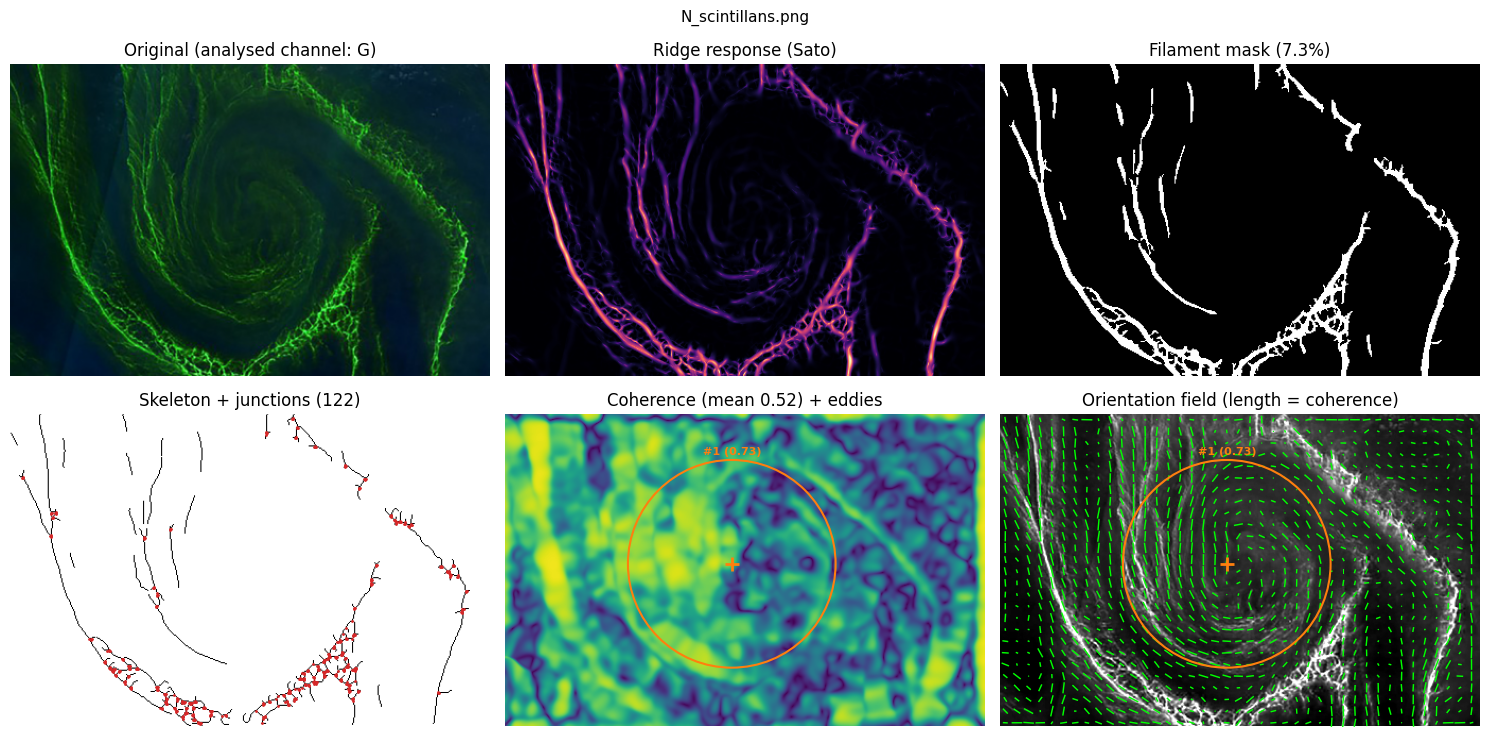

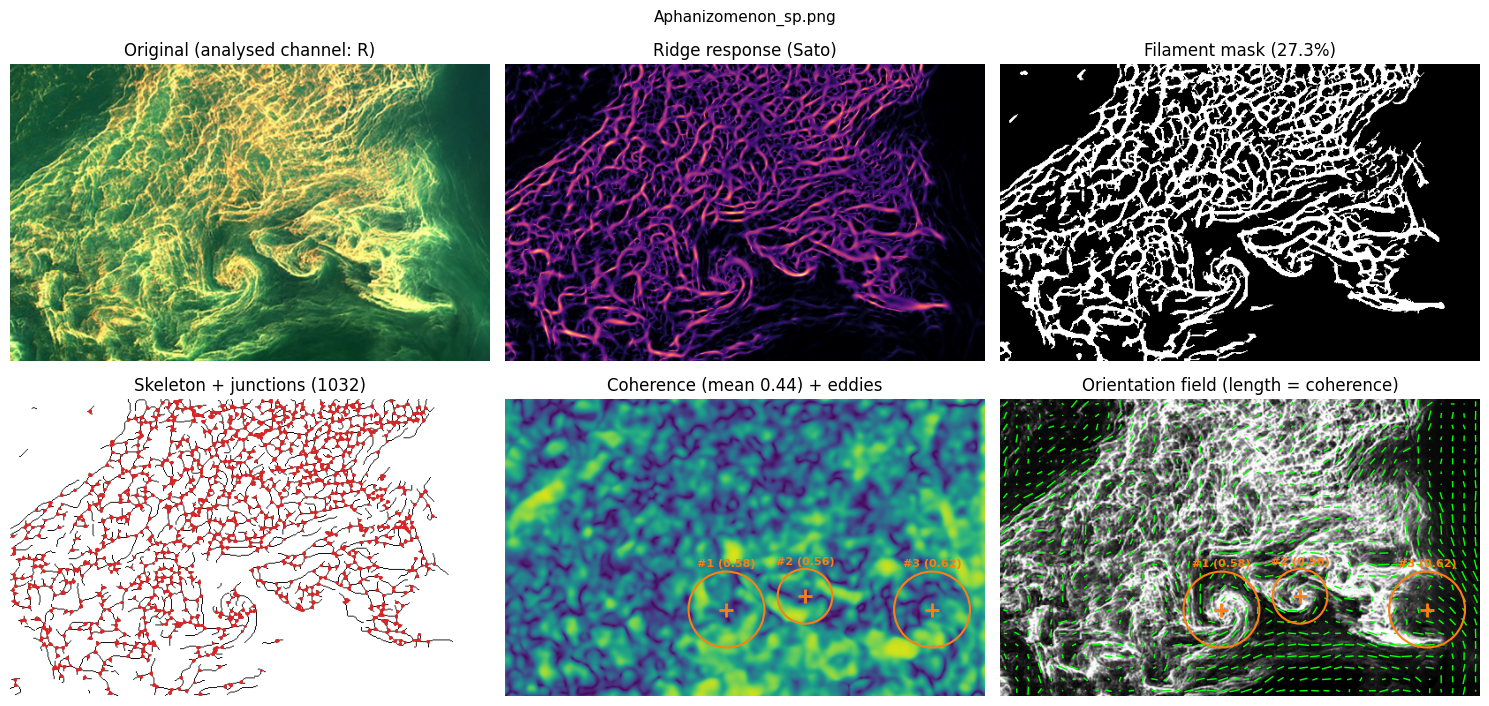

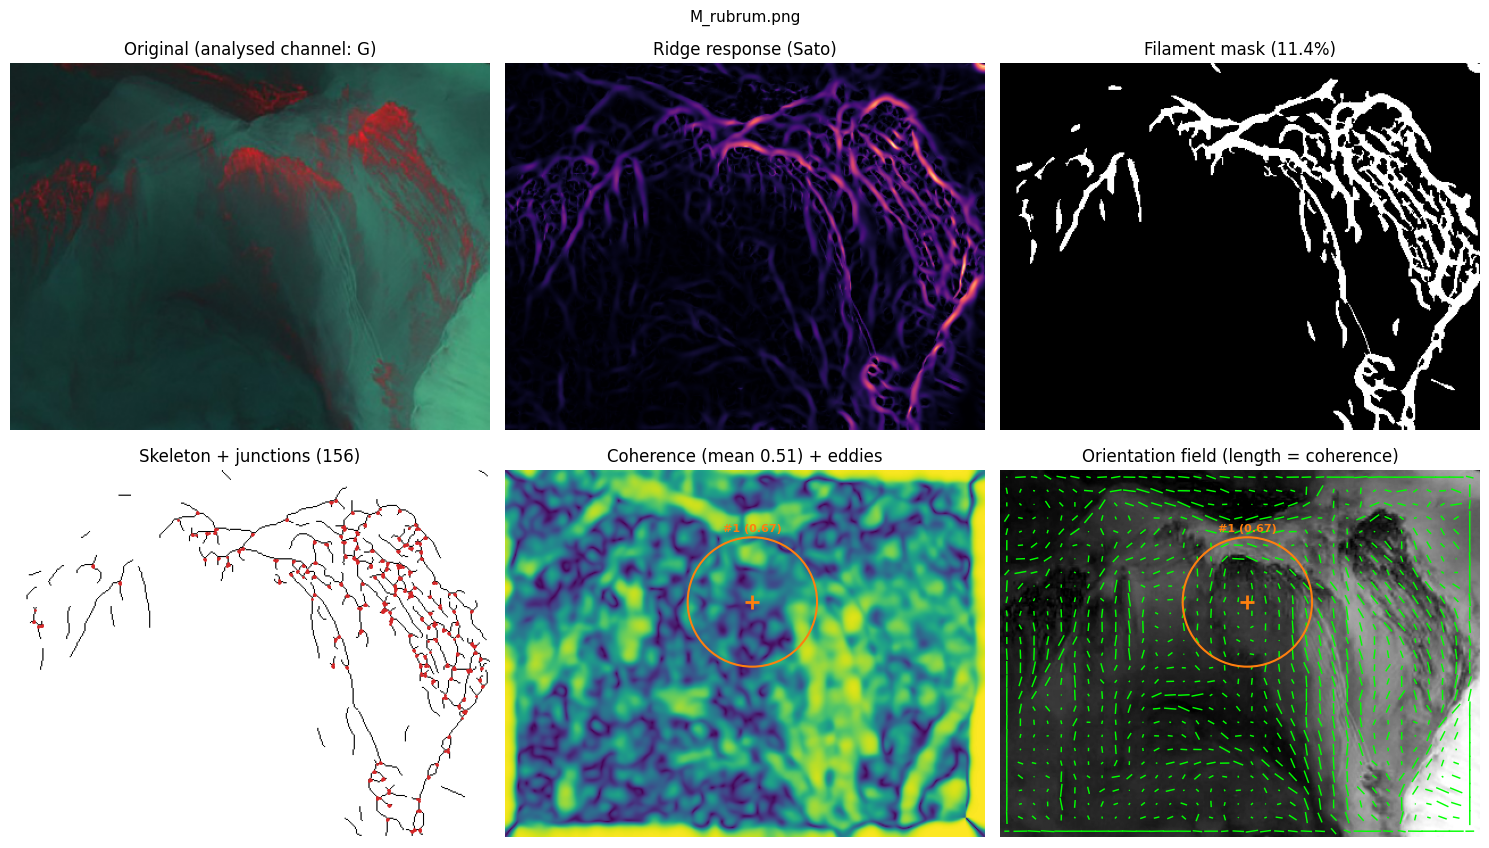

In [6]:
for name, d in diags.items():
    fig = d.plot()   # no path: returns the figure (passing a path switches matplotlib to Agg)
    fig.savefig(OUT / f"{name}_diagnosis.png", dpi=110)
    d.to_json(OUT / f"{name}_diagnosis.json")

### Detected eddies

In [7]:
eddies = pd.DataFrame([
    {"image": name, "eddy": i, **{k: v for k, v in e.to_dict().items() if k != "profile"}}
    for name, d in diags.items() for i, e in enumerate(d.eddies, 1)
])
eddies

,image,eddy,x,y,radius,alignment,significance,support,coverage
0,N_scintillans,1,214.0,141.0,98.0,0.726,3.571,0.051,0.875
1,Aphanizomenon_sp,1,251.0,239.0,43.0,0.584,2.138,0.149,1.000
2,Aphanizomenon_sp,2,340.0,224.0,31.0,0.561,1.547,0.164,1.000
3,Aphanizomenon_sp,3,484.0,239.0,43.0,0.624,1.515,0.066,0.750
4,M_rubrum,1,218.0,116.0,57.0,0.670,2.516,0.089,0.875


Radial alignment profile of each eddy (alignment per annulus, from the centre outwards):

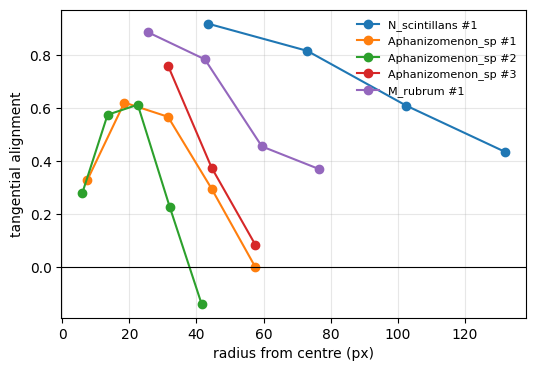

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, d in diags.items():
    for i, e in enumerate(d.eddies, 1):
        r_mid = [np.mean([float(v) for v in k.split("-")]) for k in e.profile]
        ax.plot(r_mid, list(e.profile.values()), "o-", label=f"{name} #{i}")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("radius from centre (px)")
ax.set_ylabel("tangential alignment")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)

### Scalar metrics side by side

In [9]:
metrics = pd.DataFrame({name: d.scalar_metrics() for name, d in diags.items()})
metrics

,N_scintillans,Aphanizomenon_sp,M_rubrum
filament_fraction,0.073,0.273,0.114
skeleton_length_px,2633.000,15076.000,3584.000
skeleton_density,19.703,82.235,26.151
n_components,21.000,31.000,31.000
n_junctions,122.000,1032.000,156.000
n_endpoints,141.000,788.000,201.000
junction_endpoint_ratio,0.865,1.310,0.776
junctions_per_100px,4.633,6.845,4.353
n_branches,132.000,985.000,237.000
branch_length_mean,12.598,6.750,10.241


## 3. Discriminate the three species

Already computed `Diagnosis` objects can be passed directly, so the images are not analysed
again. Each image is cut into 64 px tiles with 50 % overlap and 13 features are computed per
tile.

In [10]:
res = s2s.discriminate(list(diags.values()), labels=list(diags), tile=64, overlap=0.5, n_select=4)
print(res.summary())

shades2shapes discrimination
  3 image(s), 3 class(es), 347 tiles
  - [N_scintillans] N_scintillans.png (channel G, 104 tiles)
  - [Aphanizomenon_sp] Aphanizomenon_sp.png (channel R, 143 tiles)
  - [M_rubrum] M_rubrum.png (channel G, 100 tiles)

Feature ranking (tile level; separability 0 = none, 1 = perfect)
                feature  separability  mean_pairwise_auc  eta2
          glcm_contrast         0.662              0.905 0.579
            lbp_entropy         0.605              0.852 0.318
       glcm_homogeneity         0.563              0.877 0.637
 glcm_correlation_decay         0.379              0.839 0.442
lbp_nonuniform_fraction         0.370              0.840 0.467
             lacunarity         0.352              0.761 0.021
      filament_fraction         0.160              0.755 0.404
       skeleton_density         0.137              0.766 0.455

Recommended feature set: glcm_contrast, lbp_entropy, glcm_correlation_decay, lbp_nonuniform_fraction
LDA accuracy, all fe

### Feature ranking

*separability* = 2 × min over class pairs of |AUC − 0.5| (0 = none, 1 = perfect).

In [11]:
res.ranking

,feature,description,separability,mean_pairwise_auc,eta2,kruskal_H,kruskal_p,mean[N_scintillans],sd[N_scintillans],mean[Aphanizomenon_sp],sd[Aphanizomenon_sp],mean[M_rubrum],sd[M_rubrum]
0,glcm_contrast,GLCM contrast (d=1),0.662,0.905,0.579,219.690,1.972e-48,6.372,5.714,16.708,7.668,0.662,0.561
1,lbp_entropy,LBP entropy,0.605,0.852,0.318,175.371,8.293e-39,3.206,0.067,3.239,0.017,3.159,0.055
2,glcm_homogeneity,GLCM homogeneity (d=1),0.563,0.877,0.637,203.536,6.349e-45,0.701,0.113,0.406,0.170,0.816,0.094
3,glcm_correlation_decay,GLCM correlation decay (d4/d1),0.379,0.839,0.442,161.592,8.144e-36,0.651,0.112,0.539,0.178,0.837,0.090
4,lbp_nonuniform_fraction,LBP non-uniform pattern fraction,0.370,0.840,0.467,186.763,2.785e-41,0.170,0.021,0.197,0.012,0.157,0.022
5,lacunarity,Lacunarity (8 px box),0.352,0.761,0.021,97.486,6.779e-22,41.536,168.823,10.012,46.854,11.478,28.118
6,filament_fraction,Filament area fraction,0.160,0.755,0.404,123.122,1.838e-27,0.071,0.063,0.303,0.146,0.131,0.138
7,skeleton_density,Skeleton density (px / 1000 px^2),0.137,0.766,0.455,136.344,2.473e-30,19.888,18.384,92.755,47.303,31.599,33.139
8,coherence,Structure-tensor coherence,0.096,0.626,0.098,28.575,6.239e-07,0.523,0.137,0.440,0.091,0.500,0.110
9,orientation_order,Orientation order R,0.067,0.618,0.063,24.200,5.558e-06,0.746,0.184,0.626,0.198,0.641,0.227


In [12]:
print("Recommended non-redundant set:", res.selected)
for name, cv in [("all features", res.cv_all), ("selected set", res.cv_selected)]:
    print(f"\nLDA, {name}: accuracy {cv['accuracy']:.1%}  [{cv['scheme']}]")
    display(cv["confusion"])

Recommended non-redundant set: ['glcm_contrast', 'lbp_entropy', 'glcm_correlation_decay', 'lbp_nonuniform_fraction']

LDA, all features: accuracy 88.9%  [5-fold over tiles (optimistic: single image per class)]


,Aphanizomenon_sp,M_rubrum,N_scintillans
Aphanizomenon_sp,123,3,16
M_rubrum,0,73,4
N_scintillans,8,3,77



LDA, selected set: accuracy 80.4%  [5-fold over tiles (optimistic: single image per class)]


,Aphanizomenon_sp,M_rubrum,N_scintillans
Aphanizomenon_sp,120,3,20
M_rubrum,0,83,17
N_scintillans,13,15,76


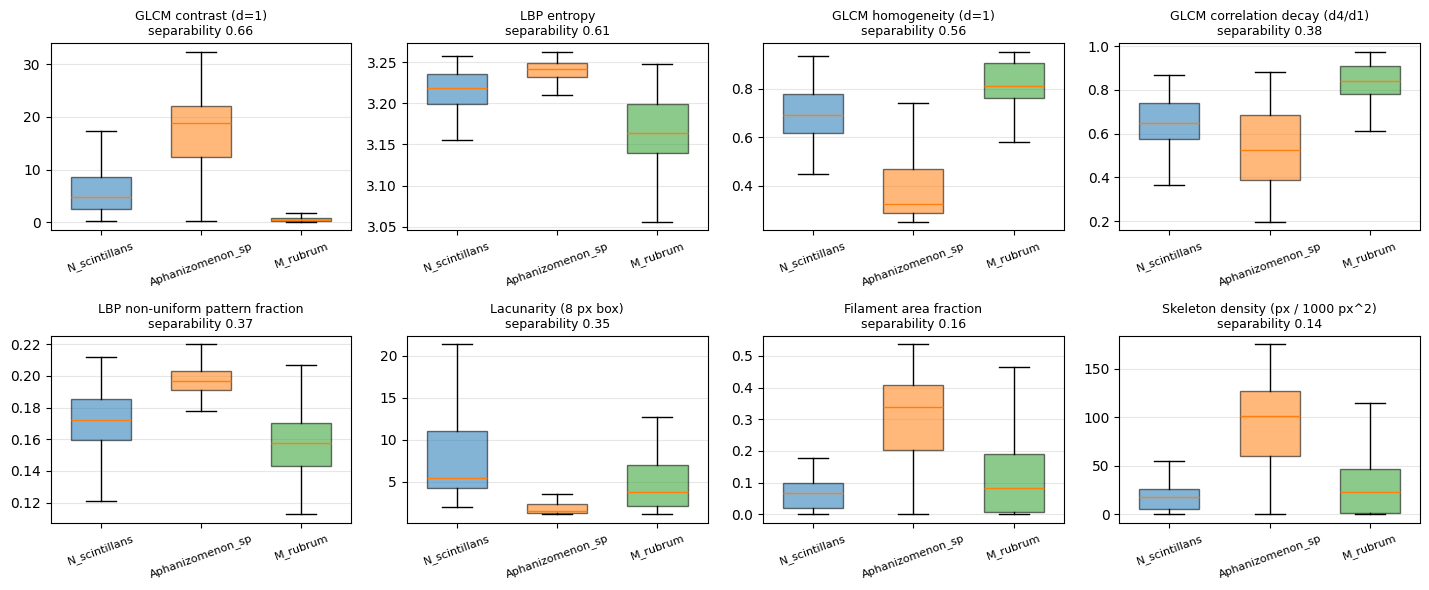

In [13]:
fig = res.plot_features(top=8)

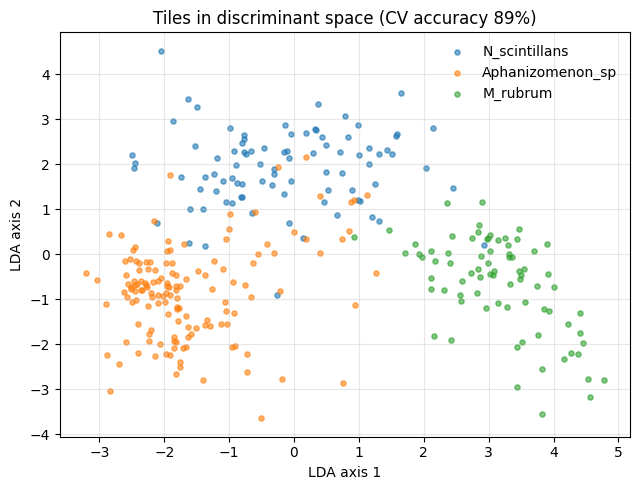

In [14]:
fig = res.plot_projection()

### Whole-image comparison

In [15]:
res.image_table

,N_scintillans.png,Aphanizomenon_sp.png,M_rubrum.png
filament_fraction,0.073,0.273,0.114
skeleton_density,19.703,82.235,26.151
junction_endpoint_ratio,0.865,1.31,0.776
junctions_per_100px,4.633,6.845,4.353
branch_length_median,6.0,5.0,7.0
n_cells,25.0,279.0,23.0
coherence_mean,0.523,0.442,0.511
orientation_order,0.474,0.276,0.257
n_eddies,1.0,3.0,1.0
eddy_max_significance,3.571,2.138,2.516


### Save the results

`save` writes `summary.txt`, the CSV tables and `discrimination.json`. Figures are saved from
the returned figure objects to keep the inline backend active.

In [16]:
res.save(OUT, plots=False)
res.plot_features().savefig(OUT / "feature_distributions.png", dpi=110)
res.plot_projection().savefig(OUT / "projection.png", dpi=110)
plt.close("all")
sorted(p.name for p in OUT.iterdir())

['Aphanizomenon_sp_diagnosis.json',
 'Aphanizomenon_sp_diagnosis.png',
 'M_rubrum_diagnosis.json',
 'M_rubrum_diagnosis.png',
 'N_scintillans_diagnosis.json',
 'N_scintillans_diagnosis.png',
 'discrimination.json',
 'feature_distributions.png',
 'feature_ranking.csv',
 'projection.png',
 'summary.txt',
 'tile_features.csv',
 'whole_image_metrics.csv']

## 4. A more honest accuracy estimate

With one image per class, the cross-validation splits tiles of the same image between
training and test sets, so accuracy is optimistic. A cheap check is to split each image in
two halves and treat each half as a separate image: every class then has two "images" and
`discriminate` switches to leave-one-image-out validation.

In [17]:
def halves(path):
    img = io.imread(path)
    H, W = img.shape[:2]
    if W >= H:
        return [img[:, : W // 2], img[:, W // 2 :]]
    return [img[: H // 2], img[H // 2 :]]

half_imgs, half_labels, half_channels = [], [], []
for name, path in IMAGES.items():
    for h in halves(path):
        half_imgs.append(h)
        half_labels.append(name)
        half_channels.append(diags[name].channel.lower())  # same band as the full image

res_h = s2s.discriminate(half_imgs, labels=half_labels, channels=half_channels)
print(f"scheme: {res_h.cv_all['scheme']}")
print(f"LDA accuracy, all {len(res_h.cv_all['features'])} features: {res_h.cv_all['accuracy']:.1%}")
print(f"LDA accuracy, selected {res_h.selected}: {res_h.cv_selected['accuracy']:.1%}")

scheme: leave-one-image-out
LDA accuracy, all 13 features: 50.5%
LDA accuracy, selected ['glcm_contrast', 'lbp_entropy', 'glcm_correlation_decay', 'lbp_nonuniform_fraction']: 58.3%


A small, non-redundant feature set usually generalises better than all 13 features,
which overfit the image they were trained on. Validate on several real images per class
before trusting a classifier.

## 5. Classify new tiles

`cv_selected["model"]` is the LDA pipeline refitted on all tiles. Here it labels the tiles of
the three images and the result is mapped back onto the image (for real use, apply it to tiles
of a new image, computed with `s2s.tile_features`).

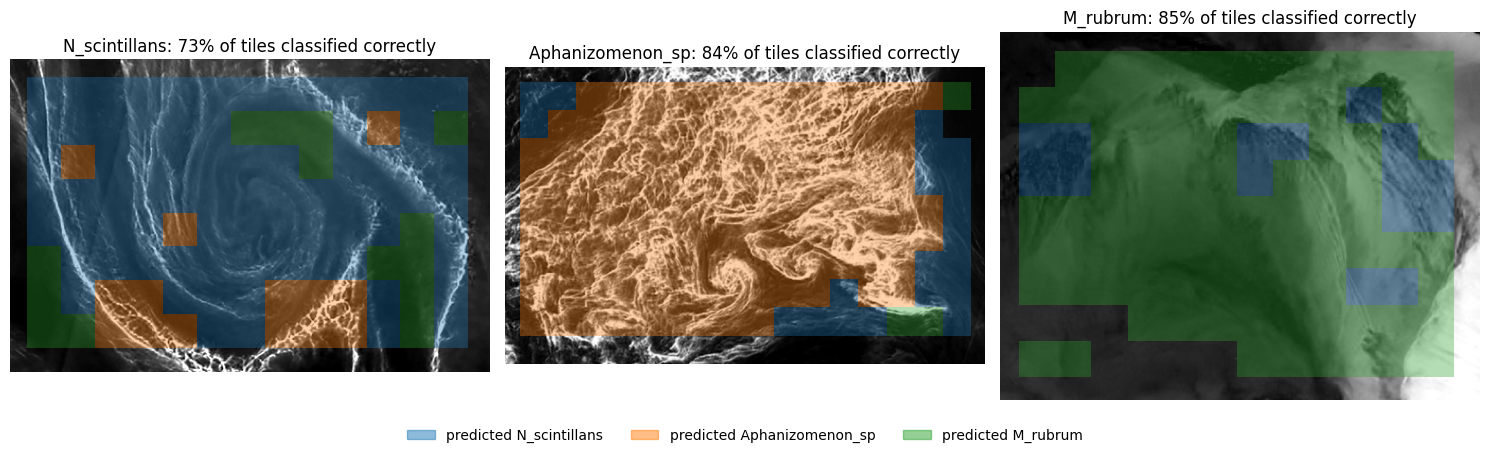

In [18]:
model = res.cv_selected["model"]
tile = 64
colors = dict(zip(diags, plt.rcParams["axes.prop_cycle"].by_key()["color"]))
fig, axes = plt.subplots(1, len(diags), figsize=(5 * len(diags), 4.5))
for ax, (name, d) in zip(axes, diags.items()):
    t = s2s.tile_features(d, tile=tile, overlap=0.5).dropna(subset=res.selected)
    t["pred"] = model.predict(t[res.selected].to_numpy())
    ax.imshow(d.band, cmap="gray")
    for _, row in t.iterrows():
        ax.add_patch(plt.Rectangle((row.x + tile / 4, row.y + tile / 4), tile / 2, tile / 2,
                                   color=colors[row["pred"]], alpha=0.35, lw=0))
    ax.set_title(f"{name}: {np.mean(t['pred'] == name):.0%} of tiles classified correctly")
    ax.axis("off")
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.5) for c in colors.values()],
           labels=[f"predicted {n}" for n in colors], loc="lower center", ncol=len(colors), frameon=False)
fig.tight_layout(rect=(0, 0.05, 1, 1))

## Command-line equivalent

```bash
cd examples
shades2shapes discriminate N_scintillans.png Aphanizomenon_sp.png M_rubrum.png \
    --labels N_scintillans,Aphanizomenon_sp,M_rubrum -o out_discrimination --save-diagnoses
```